# Credit Risk Decision System for Smarter Loan Approvals
This project is to build a system for the lending club to predict the likelihood of loan default using borrower financial and credit history in order to support better lending decisions. The dataset from the platform is shared as loans_full_schema.

## Dataset Description
- emp_title: Job title.
- emp_length: Number of years in the job, rounded down. If longer than 10 years, then this is represented by the value 10.
- state: Two-letter state code.
- homeownership: The ownership status of the applicant's residence.
- annual_income: Annual income.
- verified_income: Type of verification of the applicant's income.
- debt_to_income: Debt-to-income ratio.
- annual_income_joint: If this is a joint application, then the annual income of the two parties applying.
- verification_income_joint: Type of verification of the joint income.
- debt_to_income_joint: Debt-to-income ratio for the two parties.
- delinq_2y: Delinquencies on lines of credit in the last 2 years.
- months_since_last_delinq: Months since the last delinquency.
- earliest_credit_line: Year of the applicant's earliest line of credit
- inquiries_last_12m: Inquiries into the applicant's credit during the last 12 months.
- total_credit_lines: Total number of credit lines in this applicant's credit history.
- open_credit_lines: Number of currently open lines of credit.
- total_credit_limit: Total available credit, e.g. if only credit cards, then the total of all the credit limits. This excludes a mortgage.
- total_credit_utilized: Total credit balance, excluding a mortgage.
- num_collections_last_12m: Number of collections in the last 12 months. This excludes medical collections.
- num_historical_failed_to_pay: The number of derogatory public records, which roughly means the number of times the applicant failed to pay.
- months_since_90d_late: Months since the last time the applicant was 90 days late on a payment.
- current_accounts_delinq: Number of accounts where the applicant is currently delinquent.
- total_collection_amount_ever: The total amount that the applicant has had against them in collections.
- current_installment_accounts: Number of installment accounts, which are (roughly) accounts with a fixed payment amount and period. A typical example might be a 36-month car loan.
- accounts_opened_24m: Number of new lines of credit opened in the last 24 months.
- months_since_last_credit_inquiry: Number of months since the last credit inquiry on this applicant.
- num_satisfactory_accounts: Number of satisfactory accounts.
- num_accounts_120d_past_due: Number of current accounts that are 120 days past due.
- num_accounts_30d_past_due: Number of current accounts that are 30 days past due.
- num_active_debit_accounts: Number of currently active bank cards.
- total_debit_limit: Total of all bank card limits.
- num_total_cc_accounts: Total number of credit card accounts in the applicant's history.
- num_open_cc_accounts: Total number of currently open credit card accounts.
- num_cc_carrying_balance: Number of credit cards that are carrying a balance.
- num_mort_accounts: Number of mortgage accounts.
- account_never_delinq_percent: Percent of all lines of credit where the applicant was never delinquent.
- tax_liens: a numeric vector
- public_record_bankrupt: Number of bankruptcies listed in the public record for this applicant.
- loan_purpose: The category for the purpose of the loan.
- application_type: The type of application: either individual or joint.
- loan_amount: The amount of the loan the applicant received.
- term: The number of days for loan repayment.
- interest_rate: Interest rate of the loan the applicant received.
- installment: Monthly payment for the loan received.
- grade: Grade associated with the loan.
- sub_grade: Detailed grade associated with the loan.
- issue_month: Month the loan was issued.
- loan_status: Status of the loan.
- initial_listing_status: Initial listing status of the loan. (whether the lender provided the entire loan or if the loan is across multiple lenders.)
- disbursement_method: Dispersement method of the loan.
- balance: Outstanding balance on the loan.
- paid_total: Total installments paid.
- paid_principal: The difference between the original loan amount and the current balance on the loan (Deposit made).
- paid_interest: The total amount of interest paid on the loan.
- paid_late_fees: Late fees paid by the applicant.

## Files
Data has been collected and stored as csv.

## What is expected
- Who will default?
- Identify both financial and credit history
- Predict the likelihood of loan default

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import credit

In [2]:
#loading csv
df = pd.read_csv('loans_full_schema.csv')
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [3]:
#checking shape
df.shape

(10000, 55)

In [4]:
#checking info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [5]:
# columns with null values
for col in df:
    if df[col].count() < 10000:
        print(df[col].name)

emp_title
emp_length
debt_to_income
annual_income_joint
verification_income_joint
debt_to_income_joint
months_since_last_delinq
months_since_90d_late
months_since_last_credit_inquiry
num_accounts_120d_past_due


In [6]:
# checking the 10 columns with null values
print(f"Missing employee titles are: {df['emp_title'].isna().sum()}")
print(f"Missing employee number of years are: {df['emp_length'].isna().sum()}")
print(f"Missing debt to income ratio are: {df['debt_to_income'].isna().sum()}")
print(f"Missing annual income joint are: {df['annual_income_joint'].isna().sum()}")
print(f"Missing verification income (joint) are: {df['verification_income_joint'].isna().sum()}")
print(f"Missing debt to income (joint) are: {df['debt_to_income_joint'].isna().sum()}")
print(f"Missing months since the last delinquency are: {df['months_since_last_delinq'].isna().sum()}")
print(f"Missing months for 90 days late payment are: {df['months_since_90d_late'].isna().sum()}")
print(f"Missing months since last credit inquiry was made are: {df['months_since_last_credit_inquiry'].isna().sum()}")
print(f"Missing number of accounts with 120 days past payment are: {df['num_accounts_120d_past_due'].isna().sum()}")

Missing employee titles are: 833
Missing employee number of years are: 817
Missing debt to income ratio are: 24
Missing annual income joint are: 8505
Missing verification income (joint) are: 8545
Missing debt to income (joint) are: 8505
Missing months since the last delinquency are: 5658
Missing months for 90 days late payment are: 7715
Missing months since last credit inquiry was made are: 1271
Missing number of accounts with 120 days past payment are: 318


In [7]:
#checking dataset by application types
df['application_type'].value_counts().to_frame()

,count
application_type,
individual,8505
joint,1495


## Data Preprocessing

In [8]:
# renaming some columns
df = df.rename(columns={'balance': 'outstanding_balance', 'installment': 'installments_amount', 'paid_interest': 'total_interest_paid'})
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,outstanding_balance,paid_total,paid_principal,total_interest_paid,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


# Exploratory Data Analysis

In [9]:
# using defined function to impute missing values
df = credit.impute_values(df, 'emp_title')
df = credit.impute_values(df, 'emp_title')
df = credit.impute_values(df, 'emp_length')
df = credit.impute_values(df, 'debt_to_income')
df = credit.impute_values(df, 'annual_income_joint')
df = credit.impute_values(df, 'verification_income_joint')
df = credit.impute_values(df, 'debt_to_income_joint')
df = credit.impute_values(df, 'months_since_last_delinq')
df = credit.impute_values(df, 'months_since_90d_late')
df = credit.impute_values(df, 'months_since_last_credit_inquiry')
df = credit.impute_values(df, 'num_accounts_120d_past_due')

In [10]:
# checking info after imputing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         10000 non-null  object 
 1   emp_length                        10000 non-null  float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    10000 non-null  float64
 7   annual_income_joint               10000 non-null  float64
 8   verification_income_joint         10000 non-null  object 
 9   debt_to_income_joint              10000 non-null  float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          10000 non-null  float64
 12  earli

In [11]:
# splitting issue_month column into year and month columns to find the length of credit history
df['issue_date'] = pd.to_datetime(df['issue_month'])
df['issue_year'] = df['issue_date'].dt.year
df['issue_month'] = df['issue_date'].dt.month

# changing dtypes
df['months_since_90d_late'] = df['months_since_90d_late'].astype('int')
df['num_accounts_120d_past_due'] = df['num_accounts_120d_past_due'].astype('int')
df['months_since_last_delinq'] = df['months_since_last_delinq'].astype('int')
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].astype('int')

In [12]:
# creating new columns to merge some columns
df = credit.consolidating_columns(df)
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,paid_total,paid_principal,total_interest_paid,paid_late_fees,issue_date,issue_year,total_income_annual,debt_ratio,income_verification,default_flag
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,0.0,Not Applicable,0.00,...,1999.33,984.14,1015.19,0.0,2018-03-01,2018,90000.0,18.01,Verified,Non_Default
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,0.0,Not Applicable,0.00,...,499.12,348.63,150.49,0.0,2018-02-01,2018,40000.0,5.04,Not Verified,Non_Default
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,0.0,Not Applicable,0.00,...,281.80,175.37,106.43,0.0,2018-02-01,2018,40000.0,21.15,Source Verified,Non_Default
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,0.0,Not Applicable,0.00,...,3312.89,2746.74,566.15,0.0,2018-01-01,2018,30000.0,10.16,Not Verified,Non_Default
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,2324.65,1569.85,754.80,0.0,2018-03-01,2018,57000.0,37.66,Verified,Non_Default


In [13]:
# preview info to see new columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 61 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   emp_title                         10000 non-null  object        
 1   emp_length                        10000 non-null  float64       
 2   state                             10000 non-null  object        
 3   homeownership                     10000 non-null  object        
 4   annual_income                     10000 non-null  float64       
 5   verified_income                   10000 non-null  object        
 6   debt_to_income                    10000 non-null  float64       
 7   annual_income_joint               10000 non-null  float64       
 8   verification_income_joint         10000 non-null  object        
 9   debt_to_income_joint              10000 non-null  float64       
 10  delinq_2y                         10000 non-nul

## Who will default?

In [14]:
df.columns

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankr

In [16]:
new_df = df.drop(['emp_length', 'state', 'homeownership','emp_title', 'interest_rate','installments_amount', 'income_verification','debt_ratio',
                     'annual_income', 'verified_income', 'debt_to_income', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint',
                     'installments_amount', 'grade', 'sub_grade', 'issue_month', 'loan_status', 'initial_listing_status','num_open_cc_accounts',
                    'disbursement_method', 'outstanding_balance', 'paid_total', 'paid_principal', 'total_interest_paid', 'paid_late_fees', 'term',
                     'issue_date', 'issue_year', 'earliest_credit_line', 'total_credit_lines','open_credit_lines', 'total_credit_utilized',
                    'num_accounts_30d_past_due', 'months_since_last_credit_inquiry', 'months_since_90d_late','current_installment_accounts',
                  'months_since_last_delinq','delinq_2y', 'num_collections_last_12m', 'current_accounts_delinq', 'total_collection_amount_ever'
                    ], axis=1)

new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   inquiries_last_12m            10000 non-null  int64  
 1   total_credit_limit            10000 non-null  int64  
 2   num_historical_failed_to_pay  10000 non-null  int64  
 3   accounts_opened_24m           10000 non-null  int64  
 4   num_satisfactory_accounts     10000 non-null  int64  
 5   num_accounts_120d_past_due    10000 non-null  int64  
 6   num_active_debit_accounts     10000 non-null  int64  
 7   total_debit_limit             10000 non-null  int64  
 8   num_total_cc_accounts         10000 non-null  int64  
 9   num_cc_carrying_balance       10000 non-null  int64  
 10  num_mort_accounts             10000 non-null  int64  
 11  account_never_delinq_percent  10000 non-null  float64
 12  tax_liens                     10000 non-null  int64  
 13  pu

In [17]:
#selecting cat features to encode
cat_features = new_df.select_dtypes('object')
num_features = [col for col in new_df.describe().columns]
num_df = new_df[num_features]

encoded_cat_df = pd.get_dummies(cat_features, dtype='int', drop_first=True)
df_encoded = pd.concat([num_df, encoded_cat_df], axis=1)
df_encoded.head()

,inquiries_last_12m,total_credit_limit,num_historical_failed_to_pay,accounts_opened_24m,num_satisfactory_accounts,num_accounts_120d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_cc_carrying_balance,...,loan_purpose_house,loan_purpose_major_purchase,loan_purpose_medical,loan_purpose_moving,loan_purpose_other,loan_purpose_renewable_energy,loan_purpose_small_business,loan_purpose_vacation,application_type_joint,default_flag_Non_Default
0,6,70795,0,5,10,0,2,11100,14,6,...,0,0,0,1,0,0,0,0,0,1
1,1,28800,1,11,14,0,3,16500,24,4,...,0,0,0,0,0,0,0,0,0,1
2,4,24193,0,13,10,0,3,4300,14,6,...,0,0,0,0,1,0,0,0,0,1
3,0,25400,1,1,4,0,2,19400,3,2,...,0,0,0,0,0,0,0,0,0,1
4,7,69839,0,6,16,0,10,32700,20,13,...,0,0,0,0,0,0,0,0,1,1


In [17]:
# # correlations across features with the target variable
# corr = df_encoded.corr()
# corrs = corr['default_flag_Non_Default'].sort_values(ascending=False)
# corrs.to_frame()

In [18]:
# # getting the pvalues 
# column_titles = [col for col in corrs.index if col!= 'default_flag_Non_Default']
# list_coeff_pvals = {}

# for col in column_titles:
#     coeffs = pearsonr(df_encoded[col], df_encoded['default_flag_Non_Default'])[0]
#     pvals = pearsonr(df_encoded[col], df_encoded['default_flag_Non_Default'])[1]
#     list_coeff_pvals[col] = {"Correlation_Coefficients": coeffs, "P_vals": pvals}

# features_df = pd.DataFrame(list_coeff_pvals).T
# features_df

In [19]:
# # select features with p_vals < 0.05
# selected_features = features_df[features_df['P_vals'] < 0.05]
# selected_features

In [20]:
# # subsetting only the selected features
# dfm_copy = df_encoded[selected_features.index]

# dfm = pd.concat([dfm_copy, df_encoded['default_flag_Non_Default']], axis=1)
# dfm.head()

In [18]:
# assigning X and y values
X = df_encoded.drop('default_flag_Non_Default', axis=1)
y = df_encoded['default_flag_Non_Default']

In [19]:
# splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#checking shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(8000, 28)
(2000, 28)
(8000,)


In [20]:
# choosing models
lr = LogisticRegression(max_iter=1000)
gb = GradientBoostingClassifier(n_estimators=20)
rf = RandomForestClassifier(n_estimators=20, n_jobs=-1)

# fitting models
lr.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20, n_jobs=-1)

In [21]:
# predicting with models
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)
pred_gb = gb.predict(X_test)


# checking scores
print(f"f1 score for logistic regression: {f1_score(y_test, pred_lr)}")
print(f"f1 score for random forest classifier: {f1_score(y_test, pred_rf)}")
print(f"f1 score for gradient boosting: {f1_score(y_test, pred_gb)}")

f1 score for logistic regression: 0.9909182643794148
f1 score for random forest classifier: 0.9909182643794148
f1 score for gradient boosting: 0.98989898989899


In [22]:
#printing report for logistic regression
print(classification_report(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000

[[   0   36]
 [   0 1964]]


In [23]:
#printing report for gradient boosting
print(classification_report(y_test, pred_gb))
print(confusion_matrix(y_test, pred_gb))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.49      2000
weighted avg       0.96      0.98      0.97      2000

[[   0   36]
 [   4 1960]]


In [24]:
#printing report
print(classification_report(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000

[[   0   36]
 [   0 1964]]


## Rebuilding Model before transferring

In [25]:
# using all features
X_all = df_encoded.drop('default_flag_Non_Default', axis=1)
y_all = df_encoded['default_flag_Non_Default']

#converting features into array
X_all = np.array(X_all)
y_all = np.array(y_all)

In [26]:
# making copies of train and test sets
X_train_kb, X_test_kb, y_train_kb, y_test_kb = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y)

# scale X
scaler = StandardScaler()
X_train_kb_scaled = scaler.fit_transform(X_train_kb)
X_test_kb_scaled = scaler.transform(X_test_kb)

In [40]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

#creating kbest object
selector = SelectKBest(score_func=mutual_info_classif, k='all')
selector.fit(X_train_kb_scaled, y_train_kb)

#get index of features sorted by scores
sorted_index = np.argsort(selector.scores_)[::-1]

list_of_f_scores_lr = []

#setting max for k range
max_length = len(X_all) + 1

# finding kbest values
for k in range(1, max_length):
    selected_features = sorted_index[:k]

    if isinstance(X_train_kb, pd.DataFrame):
        selected_X_train_kb = X_train_kb_scaled.iloc[:, selected_features]
        selected_X_test_kb = X_test_kb_scaled.iloc[:, selected_features]
    else:
        selected_X_train_kb = X_train_kb_scaled[:, selected_features]
        selected_X_test_kb = X_test_kb_scaled[:, selected_features]

    #training models
    lr.fit(selected_X_train_kb, y_train_kb)

    #make predictions
    lr_kbest_pred = lr.predict(selected_X_test_kb)

    #get scores
    f1_scores_lr_kbest = round(f1_score(y_test_kb, lr_kbest_pred, average='weighted'), 3)

    #append list with scores
    list_of_f_scores_lr.append(f1_scores_lr_kbest)

In [46]:
len(list_of_f_scores_lr)

10000

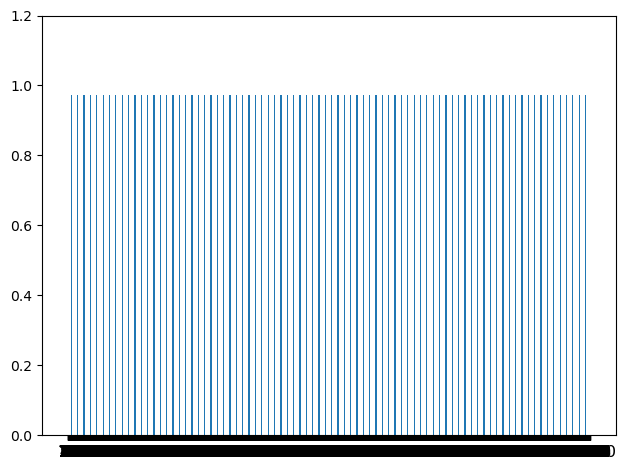

In [49]:
# plot f1 scores
fig, ax = plt.subplots()

x = np.arange(1, max_length)
y = list_of_f_scores_lr

ax.bar(x, y, width=0.2)
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=12)
ax.set_ylim(0, 1.2)
plt.tight_layout()

In [32]:
# creating a pipeline for logistic regression
lr_1 = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(class_weight='balanced', max_iter=1000))
])
rf_1 = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
gb_1 = GradientBoostingClassifier(random_state=42)


# fitting models
lr_1.fit(X_train, y_train)
gb_1.fit(X_train, y_train)
rf_1.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [33]:
# predicting probabilities with models
lr_probs = lr_1.predict_proba(X_test)[:, 1]
rf_probs = rf_1.predict_proba(X_test)[:, 1]
gb_probs = gb_1.predict_proba(X_test)[:, 1]

In [34]:
# checking important metrics for logistic regression
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, lr_probs)
print(precision)
print(recall)
print(thresholds)

[0.982      0.981991   0.98248248 ... 1.         1.         1.        ]
[1.00000000e+00 9.99490835e-01 9.99490835e-01 ... 1.01832994e-03
 5.09164969e-04 0.00000000e+00]
[0.12169851 0.15176716 0.18161197 ... 0.82109935 0.82220535 0.88389104]


In [35]:
# prediction for logistic regression
y_pred_lr = (lr_probs > 0.3).astype(int)
y_pred_lr

array([1, 1, 1, ..., 1, 1, 1])

In [36]:
#print report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.10      0.08      0.09        36
           1       0.98      0.99      0.99      1964

    accuracy                           0.97      2000
   macro avg       0.54      0.54      0.54      2000
weighted avg       0.97      0.97      0.97      2000



In [37]:
# for random forest
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)
# print(precision)
# print(recall)
# print(thresholds)

In [38]:
# prediction for random forest
y_pred_rf = (rf_probs > 0.3).astype(int)
y_pred_rf

array([1, 1, 1, ..., 1, 1, 1])

In [39]:
#print report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



In [40]:
# selecting logistic regression since it was more efficient
proba_non_default = lr_1.predict_proba(X_test)[:, 1]
proba_default = 1 - proba_non_default
proba_default

array([0.53689473, 0.49408075, 0.40096018, ..., 0.42955239, 0.66954283,
       0.45067579])

In [48]:
lr_1.predict_proba(X_test)

array([[0.53689473, 0.46310527],
       [0.49408075, 0.50591925],
       [0.40096018, 0.59903982],
       ...,
       [0.42955239, 0.57044761],
       [0.66954283, 0.33045717],
       [0.45067579, 0.54932421]])

In [41]:
# create a credit score
credit_score = 850 - (proba_default * 550)
credit_score = credit_score.round().astype(int)
bands = []

for score in credit_score:
    if score >= 750:
        bands.append("Excellent")
    elif score >= 700:
        bands.append("Very Good")
    elif score >= 650:
        bands.append("Good")
    elif score >= 600:
        bands.append("Fair")
    else:
        bands.append("Poor")

cs_band = bands
# cs_band

In [42]:
# making approvals based on credit score
approval = []

for score in credit_score:
    if score >= 700:
        approval.append("Approve")
    elif score >= 620:
        approval.append("Manual Review")
    else:
        approval.append("Decline")

decisions = approval
# decisions

In [43]:
# how final result df should be
results = X_test.copy()
results['proba_default'] = proba_default
results['credit_score'] = credit_score
results['cs_band'] = cs_band
results['decision'] = decisions

results[['proba_default', 'credit_score', 'cs_band', 'decision']].head()

,proba_default,credit_score,cs_band,decision
1466,0.536895,555,Poor,Decline
2782,0.494081,578,Poor,Decline
4275,0.400960,629,Fair,Manual Review
2163,0.448341,603,Fair,Decline
1429,0.522228,563,Poor,Decline


## Transferring Model

In [44]:
# preparing to transfer model and scaler
import pickle
model = lr_1

# saving the trained model
filename = 'trained_model.pkl'
pickle.dump(model, open(filename, 'wb'))

In [45]:
try:
    with open('trained_model.pkl', 'rb') as file:
        model = pickle.load(file)
except Exception as e:
    st.error(f"Error loading model: {e}")

input_data = np.array([0, 0, 0, 0, 0, 1]).reshape(1, -1)

pred = model.predict(input_data)
prob = model.predict_proba(input_data)[:]
print(pred)

if pred == 0:
    print(f"Likely to default (Risk: {prob[:, 1]})")
else:
    print(f"Less likely to default (Safe: {prob[:, 1]})")

[0]
Likely to default (Risk: [0.28450725])


In [52]:
np.array([0, 0, 0, 0, 5, 0]).reshape(1, -1)

array([[0, 0, 0, 0, 5, 0]])